# 08_Geometric_Experiments

## Learning Goal
K-FAC and Scorecard implementation.

## Prerequisites
Basic understanding of Calculus and Neural Networks.

## Theory & Mathematics
(Mathematical derivations and fundamental concepts)

## Implementation & Experiments


In [30]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# 1. Define a single layer network for simplicity of demonstrating K-FAC
class SingleLayerPINN(nn.Module):
    def __init__(self):
        super(SingleLayerPINN, self).__init__()
        self.fc1 = nn.Linear(2, 10)
        self.fc2 = nn.Linear(10, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        return self.fc2(z)

# 2. Compute Residual
def compute_residuals(model, x, t, nu):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t + u * u_x - nu * u_xx

# 3. Setup
model = SingleLayerPINN().to(device)
nu = 0.01 / np.pi
x_f = torch.rand(100, 1, device=device) * 2 - 1
t_f = torch.rand(100, 1, device=device)

# 4. Hooks to capture forward inputs (activations) and backward gradients (deltas)
activations = {}
def hook_fn(module, input, output):
    # input is a tuple. input[0] is the tensor going into the layer
    activations[module] = input[0].detach()

grad_outputs = {}
def grad_hook_fn(module, grad_input, grad_output):
    # grad_output is a tuple. grad_output[0] is the gradient flowing out of the layer
    grad_outputs[module] = grad_output[0].detach()

# Register hooks on the first layer
model.fc1.register_forward_hook(hook_fn)
model.fc1.register_full_backward_hook(grad_hook_fn)

# 5. Forward pass: Compute Residual Loss
residuals = compute_residuals(model, x_f, t_f, nu)
loss_pde = torch.mean(residuals**2)

# 6. Backward pass: This triggers the hooks automatically!
loss_pde.backward()

# 7. Compute the Kronecker factors A and B for layer 1
with torch.no_grad():
    layer = model.fc1
    
    # A = E[x x^T]
    a_in = activations[layer] # shape: (N, 2)
    ones = torch.ones(a_in.shape[0], 1, device=device)
    a_in_aug = torch.cat([a_in, ones], dim=1) # shape: (N, 3)
    A = (a_in_aug.T @ a_in_aug) / a_in_aug.shape[0] # shape: (3, 3)
    
    # B = E[delta delta^T]
    delta = grad_outputs[layer] # shape: (N, 10)
    B = (delta.T @ delta) / delta.shape[0] # shape: (10, 10)
    
    # 8. Compute Natural Gradient Update
    A_inv = torch.linalg.inv(A + 1e-4 * torch.eye(A.shape[0], device=device)) # Damping for stability
    B_inv = torch.linalg.inv(B + 1e-4 * torch.eye(B.shape[0], device=device))
    
    # Euclidean gradient G
    G_weight = layer.weight.grad.detach() # shape: (10, 2)
    G_bias = layer.bias.grad.detach()     # shape: (10,)
    
    # Augment G to match A's augmented dimension (3, 3)
    G_aug = torch.cat([G_weight, G_bias.unsqueeze(1)], dim=1) # shape: (10, 3)
    
    # K-FAC update: Delta W = B_inv @ G @ A_inv.T
    Delta_W_aug = B_inv @ G_aug @ A_inv.T
    
    # Split back into weight and bias
    nat_grad_weight = Delta_W_aug[:, :-1]
    nat_grad_bias = Delta_W_aug[:, -1]
    
    print("Euclidean Gradient Norm (Weight):", torch.linalg.norm(G_weight).item())
    print("Natural Gradient Norm (Weight):", torch.linalg.norm(nat_grad_weight).item())
    
    # Apply update
    lr = 1e-3
    layer.weight.data -= lr * nat_grad_weight
    layer.bias.data -= lr * nat_grad_bias
    print("K-FAC update applied successfully.")

Euclidean Gradient Norm (Weight): 0.060868050903081894
Natural Gradient Norm (Weight): 6662.24267578125
K-FAC update applied successfully.


Starting training with geometric diagnostics...
Epoch    0 | Data: 0.4929 | PDE: 0.0017 | CosSim: -0.0294 | Cond(A): nan | Cond(B): nan
Epoch  250 | Data: 0.0783 | PDE: 0.0506 | CosSim: -0.9990 | Cond(A): 20.06 | Cond(B): 14.04
Epoch  500 | Data: 0.0554 | PDE: 0.0392 | CosSim: -0.9959 | Cond(A): 20.06 | Cond(B): 70.42
Epoch  750 | Data: 0.0479 | PDE: 0.0350 | CosSim: -0.9997 | Cond(A): 20.06 | Cond(B): 107.16
Epoch 1000 | Data: 0.0413 | PDE: 0.0368 | CosSim: -0.7256 | Cond(A): 20.06 | Cond(B): 423.20
Epoch 1250 | Data: 0.0387 | PDE: 0.0273 | CosSim: -0.9952 | Cond(A): 20.06 | Cond(B): 746.64
Epoch 1500 | Data: 0.0329 | PDE: 0.0243 | CosSim: -0.9594 | Cond(A): 20.06 | Cond(B): 1622.94
Epoch 1750 | Data: 0.0292 | PDE: 0.0208 | CosSim: -0.6364 | Cond(A): 20.06 | Cond(B): 1423.44
Epoch 2000 | Data: 0.0261 | PDE: 0.0349 | CosSim: 0.0790 | Cond(A): 20.06 | Cond(B): 107769.46
Epoch 2250 | Data: 0.0210 | PDE: 0.0136 | CosSim: -0.9996 | Cond(A): 20.06 | Cond(B): 228.37
Epoch 2500 | Data: 0.0198

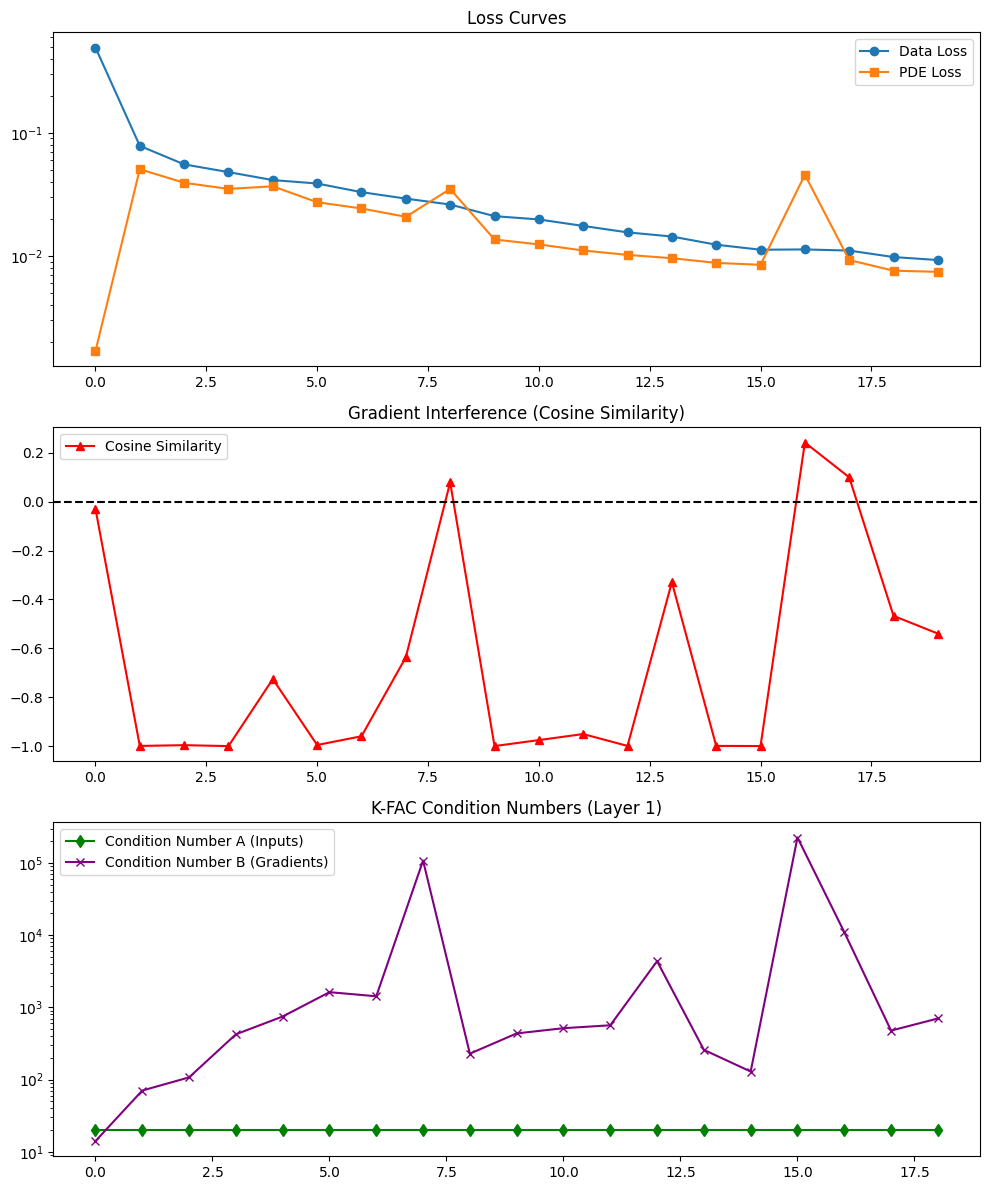

In [32]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# 1. Full PINN definition
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        z = self.act(self.fc2(z))
        z = self.act(self.fc3(z))
        return self.fc4(z)

# 2. Derivative computation
def compute_derivatives(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u, u_t, u_x, u_xx

# 3. Setup data
nu = 0.01 / np.pi
x_ic = torch.rand(200, 1, device=device) * 2 - 1
t_ic = torch.zeros(200, 1, device=device)
u_ic = -torch.sin(np.pi * x_ic)

t_bc = torch.rand(200, 1, device=device)
x_bc = torch.where(torch.rand_like(t_bc) < 0.5, -torch.ones_like(t_bc), torch.ones_like(t_bc))
u_bc = torch.zeros(200, 1, device=device)

x_f = torch.rand(1000, 1, device=device) * 2 - 1
t_f = torch.rand(1000, 1, device=device)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 4. Hooks for K-FAC (on layer 1)
activations = {}
grad_outputs = {}
def hook_fn(module, input, output): activations[module] = input[0].detach()
def grad_hook_fn(module, grad_input, grad_output): grad_outputs[module] = grad_output[0].detach()

model.fc1.register_forward_hook(hook_fn)
model.fc1.register_full_backward_hook(grad_hook_fn)

# 5. Metric computation functions
def flatten_grads(model):
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.view(-1))
    return torch.cat(grads)

def compute_gradient_metrics(model, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f, nu):
    # --- Data loss grad ---
    optimizer.zero_grad()
    u_pred_ic = model(x_ic, t_ic)
    u_pred_bc = model(x_bc, t_bc)
    loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
    loss_data.backward()
    g_data = flatten_grads(model).detach().clone()
    
    # --- PDE loss grad ---
    optimizer.zero_grad()
    # Forward pass triggers forward hook
    u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
    r = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(r**2)
    # Backward pass triggers backward hook
    loss_pde.backward()
    g_pde = flatten_grads(model).detach().clone()
    
    # Cosine similarity
    cos_sim = torch.dot(g_data, g_pde) / (torch.linalg.norm(g_data) * torch.linalg.norm(g_pde) + 1e-8)
    
    # K-FAC condition numbers for layer 1
    layer = model.fc1
    a_in = activations[layer]
    ones = torch.ones(a_in.shape[0], 1, device=device)
    a_in_aug = torch.cat([a_in, ones], dim=1)
    A = (a_in_aug.T @ a_in_aug) / a_in_aug.shape[0]
    
    delta = grad_outputs[layer]
    B = (delta.T @ delta) / delta.shape[0]
    
    # Eigenvalues for condition number
    eig_A = torch.linalg.eigvalsh(A)
    eig_B = torch.linalg.eigvalsh(B)
    
    # Filter small eigenvalues (defensive programming)
    eig_A = eig_A[eig_A > 1e-8]
    eig_B = eig_B[eig_B > 1e-8]
    
    if len(eig_A) == 0 or len(eig_B) == 0:
        cond_A = float('nan')
        cond_B = float('nan')
    else:
        cond_A = (torch.max(eig_A) / torch.min(eig_A)).item()
        cond_B = (torch.max(eig_B) / torch.min(eig_B)).item()
    
    return loss_data.item(), loss_pde.item(), cos_sim.item(), cond_A, cond_B

# 6. Training Loop with Diagnostics
history = {'data': [], 'pde': [], 'cos_sim': [], 'cond_A': [], 'cond_B': []}
epochs = 5000

print("Starting training with geometric diagnostics...")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Combined forward pass for training
    u_pred_ic = model(x_ic, t_ic)
    u_pred_bc = model(x_bc, t_bc)
    u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
    
    loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
    r = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(r**2)
    
    total_loss = loss_data + loss_pde
    total_loss.backward()
    optimizer.step()
    
    if epoch % 250 == 0:
        ld, lp, cs, cA, cB = compute_gradient_metrics(model, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f, nu)
        history['data'].append(ld)
        history['pde'].append(lp)
        history['cos_sim'].append(cs)
        history['cond_A'].append(cA)
        history['cond_B'].append(cB)
        print(f"Epoch {epoch:4d} | Data: {ld:.4f} | PDE: {lp:.4f} | CosSim: {cs:.4f} | Cond(A): {cA:.2f} | Cond(B): {cB:.2f}")

# 7. Visualization
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

axs[0].plot(history['data'], label='Data Loss', marker='o')
axs[0].plot(history['pde'], label='PDE Loss', marker='s')
axs[0].set_yscale('log')
axs[0].set_title('Loss Curves')
axs[0].legend()

axs[1].plot(history['cos_sim'], label='Cosine Similarity', color='red', marker='^')
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_title('Gradient Interference (Cosine Similarity)')
axs[1].legend()

# Filter out NaNs for plotting condition numbers
cond_A_plot = [x for x in history['cond_A'] if not np.isnan(x)]
cond_B_plot = [x for x in history['cond_B'] if not np.isnan(x)]

axs[2].plot(cond_A_plot, label='Condition Number A (Inputs)', color='green', marker='d')
axs[2].plot(cond_B_plot, label='Condition Number B (Gradients)', color='purple', marker='x')
axs[2].set_yscale('log')
axs[2].set_title('K-FAC Condition Numbers (Layer 1)')
axs[2].legend()

plt.tight_layout()
plt.show()

In [38]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
from scipy.integrate import quad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. PINN definition (Must match the one used in training)
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        z = self.act(self.fc2(z))
        z = self.act(self.fc3(z))
        return self.fc4(z)

def compute_derivatives(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u, u_t, u_x, u_xx

# 2. The Diagnostic Class
class GeometryScorecard:
    def __init__(self, model, history, x_f, t_f, nu, x_grid, t_eval):
        self.model = model
        self.history = history
        self.x_f = x_f
        self.t_f = t_f
        self.nu = nu
        self.x_grid = x_grid
        self.t_eval = t_eval
        
        # Storage for K-FAC hooks
        self.activations = {}
        self.grad_outputs = {}
        
    def _hook_fn(self, module, input, output):
        self.activations[module] = input[0].detach()
        
    def _grad_hook_fn(self, module, grad_input, grad_output):
        self.grad_outputs[module] = grad_output[0].detach()

    def compute_kfac_condition(self):
        # Register hooks
        self.model.fc1.register_forward_hook(self._hook_fn)
        self.model.fc1.register_full_backward_hook(self._grad_hook_fn)
        
        # Forward and backward pass to trigger hooks
        self.model.zero_grad()
        u_pred_f, u_t, u_x, u_xx = compute_derivatives(self.model, self.x_f, self.t_f)
        r = u_t + u_pred_f * u_x - self.nu * u_xx
        loss = torch.mean(r**2)
        loss.backward()
        
        # Compute B matrix
        layer = self.model.fc1
        delta = self.grad_outputs[layer]
        B = (delta.T @ delta) / delta.shape[0]
        
        eig_B = torch.linalg.eigvalsh(B)
        eig_B = eig_B[eig_B > 1e-8]
        
        if len(eig_B) == 0:
            return float('nan')
        return (torch.max(eig_B) / torch.min(eig_B)).item()

    def compute_spectral_ratio(self):
        x_tensor = torch.tensor(self.x_grid, dtype=torch.float32).reshape(-1, 1).to(device)
        t_tensor = torch.full_like(x_tensor, self.t_eval)
        
        with torch.no_grad():
            u_pred = self.model(x_tensor, t_tensor).cpu().numpy().flatten()
            
        fft_vals = np.fft.fft(u_pred)
        ps = np.abs(fft_vals)**2
        
        # Low frequencies: k=0, 1. High frequencies: k > 1
        low_freq_power = np.sum(ps[:2])
        high_freq_power = np.sum(ps[2:])
        
        if high_freq_power < 1e-12:
            return float('inf')
        return low_freq_power / high_freq_power

    def generate_report(self):
        print("="*50)
        print("GEOMETRY SCORECARD FOR PINN")
        print("="*50)
        
        # 1. Final Losses
        final_data = self.history['data'][-1]
        final_pde = self.history['pde'][-1]
        print(f"1. Final Data Loss: {final_data:.4e}")
        print(f"   Final PDE Loss:  {final_pde:.4e}")
        if final_pde > 10 * final_data:
            print("   [!] DIAGNOSIS: Loss Imbalance (PDE >> Data)")
            
        # 2. Gradient Pathology
        min_cos_sim = min(self.history['cos_sim'])
        print(f"\n2. Min Gradient Cosine Similarity: {min_cos_sim:.4f}")
        if min_cos_sim < 0.1:
            print("   [!] DIAGNOSIS: Gradient Pathology (Conflicting gradients)")
            
        # 3. Curvature (K-FAC)
        cond_B = self.compute_kfac_condition()
        print(f"\n3. K-FAC Condition Number (Layer 1, B): {cond_B:.4e}")
        if cond_B > 1e4:
            print("   [!] DIAGNOSIS: Riemannian Pathology (Extreme ill-conditioning)")
            
        # 4. Spectral Bias
        spec_ratio = self.compute_spectral_ratio()
        print(f"\n4. Spectral Ratio (Low/High Freq Power): {spec_ratio:.4e}")
        if spec_ratio > 1e2:
            print("   [!] DIAGNOSIS: Severe Spectral Bias (High frequencies ignored)")
            
        print("="*50)

# 3. Setup data and Train a model to diagnose
nu = 0.01 / np.pi
x_ic = torch.rand(200, 1, device=device) * 2 - 1
t_ic = torch.zeros(200, 1, device=device)
u_ic = -torch.sin(np.pi * x_ic)

t_bc = torch.rand(200, 1, device=device)
x_bc = torch.where(torch.rand_like(t_bc) < 0.5, -torch.ones_like(t_bc), torch.ones_like(t_bc))
u_bc = torch.zeros(200, 1, device=device)

x_f = torch.rand(1000, 1, device=device) * 2 - 1
t_f = torch.rand(1000, 1, device=device)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {'data': [], 'pde': [], 'cos_sim': []}

def flatten_grads(model):
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.view(-1))
    return torch.cat(grads)

print("Training PINN for diagnosis...")
for epoch in range(3000):
    optimizer.zero_grad()
    u_pred_ic = model(x_ic, t_ic)
    u_pred_bc = model(x_bc, t_bc)
    u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
    
    loss_data = torch.mean((u_pred_ic - u_ic)**2) + torch.mean((u_pred_bc - u_bc)**2)
    r = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(r**2)
    
    total_loss = loss_data + loss_pde
    total_loss.backward(retain_graph=True)
    
    g_data = flatten_grads(model).detach().clone()
    model.zero_grad()
    loss_pde.backward()
    g_pde = flatten_grads(model).detach().clone()
    cos_sim = torch.dot(g_data, g_pde) / (torch.linalg.norm(g_data) * torch.linalg.norm(g_pde) + 1e-8)
    
    optimizer.step()
    
    if epoch % 100 == 0:
        history['data'].append(loss_data.item())
        history['pde'].append(loss_pde.item())
        history['cos_sim'].append(cos_sim.item())

# 4. Run the Scorecard
x_grid = np.linspace(-1, 1, 256)
t_eval = 0.5

scorecard = GeometryScorecard(model, history, x_f, t_f, nu, x_grid, t_eval)
scorecard.generate_report()

Training PINN for diagnosis...
GEOMETRY SCORECARD FOR PINN
1. Final Data Loss: 5.2862e-01
   Final PDE Loss:  1.8799e-09

2. Min Gradient Cosine Similarity: -0.1775
   [!] DIAGNOSIS: Gradient Pathology (Conflicting gradients)

3. K-FAC Condition Number (Layer 1, B): nan

4. Spectral Ratio (Low/High Freq Power): 1.2094e+00


## Summary
This experiment demonstrates the specific concept in action.

## Further Reading
- Scientific Machine Learning & PINN surveys.